# Does Block 3 of ProNDF share computation across sources, or gate sub-blocks?

**A mechanistic-interpretability investigation of a claim from the ProNDF paper.**

The ProNDF paper (Mora, Eweis-LaBolle et al., 2023) emulates many data sources of differing
fidelity with a single network, and claims it can fit a *data-scarce* source by reusing what it
learned from data-rich sources — informally, *"learn the shape once, then shift it per source."*
This notebook tests that claim directly.

We frame it as a falsifiable dichotomy about **Block 3 (B3)**, the input→output network:

- **Possibility 1 — Modular / gating.** B3 is effectively partitioned into source-specific
  sub-blocks; the source signal *selects* which sub-block runs. Different sources would use
  *different* units, and we could lesion one source without touching another.
- **Possibility 2 — Distributed / sharing.** *All* of B3 processes *all* sources; the source
  signal merely *modulates* a shared computation (in the strongest form, a pure output shift).

These are not the only possibilities, but they are the two the paper's claim contrasts, and they
make opposite, testable predictions. We'll locate B3 on the gating↔sharing spectrum, then — *if*
it is sharing — ask what *kind* of modulation the source applies (shift vs. reshape).

### Hypotheses
- **H1 (shared shape):** per-source functions differ by a near-`x`-independent offset.
- **H2 (additive mechanism):** the source steers the output by a roughly constant amount across `x`
  (`∂f/∂x` ≈ invariant to source).
- **H3 (data-efficiency):** a scarce source inherits the rich source's shape where it has *no* data.
- **H-gating:** sources route through disjoint units (we expect to *reject* this).


## Why B3 is unusually clean to probe

Tracing the forward pass, the **only** signal that carries source identity into B3 is
`z_B1 = B1(source_onehot)` — a *constant vector per source* (deterministic here). B3 receives
`u = concat(z_B1, x)`. In B3's first layer:

$$h = W_1 u + b = \underbrace{W_1^{z} z_{B1}}_{\text{per-source constant}} + \underbrace{(W_1^{x} x + b)}_{\text{shared over } x}$$

So the source enters as a **constant, per-unit bias shift before the `tanh`**. Two consequences:

1. *"Weight sharing" is architecturally guaranteed* — there is one B3 MLP for all sources. The real
   question is **how the source knob is used**, which is what we measure.
2. Because B3 is a clean function `f(z_B1, x)` we can feed it *anything*: steering, activation
   patching, and Jacobians are all exact — no fragile hooks. The "residual stream" here is a 2-vector.

We use the 1-D `rational` benchmark: high-fidelity `yh` is **scarce** (5 points), a low-fidelity
source is **abundant** (200 points). Primary pair: `yh + yl1` (structurally similar). Divergent
contrast: `yh + yl3`. We use a **deterministic** output head (variance deferred) so B3 is a clean
`(z_B1, x) → ŷ` map, and keep the per-source loss balancing that lets the scarce source be learned.


In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, torch
import torch.nn as nn
import matplotlib.pyplot as plt
from prondf.data import MultiFidelityDataset, collate_fn
from prondf.models import Build_ProNDF
from prondf.blocks import Det_Block

SEED = 0
XLO, XHI = -2.0, 3.0

# rational source functions (1 / polynomial); see datasets/rational
def yh(c, x):  return 1.0 / (0.1*x**3 + x**2 + x + 1)   # high-fidelity  (scarce)
def yl1(c, x): return 1.0 / (0.2*x**3 + x**2 + x + 1)   # low-fidelity 1 (abundant, ~shift of yh)
def yl3(c, x): return 1.0 / (x**2 + 1)                   # low-fidelity 3 (abundant, divergent)


## Helper functions
Data generation, training (a plain full-batch loop over ProNDF's loss handler), and the probes we reuse throughout: per-source function evaluation, activation capture, ablation, and linear CKA.

In [2]:
def make_dataset(funcs, counts, ranges, noise=1e-3, seed=SEED):
    # Build a multi-source dataset; each source can have its own x-range.
    rng = np.random.default_rng(seed); S = len(funcs)
    src, xs, ys = [], [], []
    for i, (f, n, (lo, hi)) in enumerate(zip(funcs, counts, ranges)):
        x = rng.uniform(lo, hi, (n, 1))
        y = f(None, x) + rng.normal(0, np.sqrt(noise), (n, 1))
        s = np.zeros((n, S)); s[:, i] = 1
        src.append(s); xs.append(x); ys.append(y)
    meta = {'dsource': S, 'dcat': None, 'dnum': 1, 'dtargets': 1,
            'qual_in': False, 'quant_in': True, 'num_samples': list(counts)}
    return MultiFidelityDataset(source=np.vstack(src), cat=None,
                                num=np.vstack(xs), targets=np.vstack(ys), meta=meta)

def build(meta, dz=2, seed=SEED):
    torch.manual_seed(seed)
    return Build_ProNDF(dataset_meta=meta, dz_B1=dz, probabilistic_output=False,
                        loss_weighting=True, lr=1e-2, weight_decay_strength=0.0, loggers=[])

def train(model, ds, epochs=2500, seed=SEED):
    # Full-batch training via ProNDF's loss handler (per-source balanced MSE).
    torch.manual_seed(seed)
    batch = collate_fn([ds[i] for i in range(len(ds))])
    opt = model.configure_optimizers(); model.train()
    for _ in range(epochs):
        opt.zero_grad()
        outs = model.get_model_outputs(batch)
        model.loss_handler.build_loss_context(model, batch, outs)
        model.loss_handler.compute_loss_terms()
        model.loss_handler.update_loss_weights()
        loss = model.loss_handler.compute_loss()
        loss.backward(); opt.step()
    model.eval(); return float(loss)

def grid(n=400): return torch.linspace(XLO, XHI, n).unsqueeze(1)
def z_of(model, s, S):
    src = torch.zeros(1, S); src[0, s] = 1
    return model.B1(src).detach()
def f_from_z(model, z, xg):
    return model.B3(torch.cat([z.repeat(xg.shape[0], 1), xg], -1)).detach()
def f_source(model, s, xg, S):
    return f_from_z(model, z_of(model, s, S), xg)

def b3_capture(model, u):
    # Output, plus pre-tanh and post-tanh activations for each hidden layer.
    pre, post, h = [], [], u
    for layer in model.B3.architecture:
        hin = h; h = layer(h)
        if isinstance(layer, nn.Tanh):
            pre.append(hin.detach()); post.append(h.detach())
    return h, pre, post

def b3_ablate(model, u, abl):
    # abl = {hidden_layer_idx: {unit_idx: value}}; clamp those post-tanh units.
    h, t = u, 0
    for layer in model.B3.architecture:
        h = layer(h)
        if isinstance(layer, nn.Tanh):
            if t in abl:
                h = h.clone()
                for unit, val in abl[t].items(): h[:, unit] = val
            t += 1
    return h

def acts_for(model, s, xg, S):
    u = torch.cat([z_of(model, s, S).repeat(xg.shape[0], 1), xg], -1)
    _, pre, post = b3_capture(model, u); return pre, post

def linear_cka(X, Y):
    X = X - X.mean(0, keepdim=True); Y = Y - Y.mean(0, keepdim=True)
    return ((Y.T @ X).pow(2).sum() / ((X.T @ X).norm() * (Y.T @ Y).norm())).item()

def ablation_effects(model, xg, S, live=1e-4, thr=0.02):
    # Ablate each hidden unit (to its combined-source mean); measure RMSE shift of
    # each source's OWN clean function. Returns per-unit effA, effB and a summary.
    preA, postA = acts_for(model, 0, xg, S); preB, postB = acts_for(model, 1, xg, S)
    cleanA = f_source(model, 0, xg, S).squeeze(); cleanB = f_source(model, 1, xg, S).squeeze()
    uA = torch.cat([z_of(model,0,S).repeat(xg.shape[0],1), xg], -1)
    uB = torch.cat([z_of(model,1,S).repeat(xg.shape[0],1), xg], -1)
    mean_vals = [torch.cat([la,lb],0).mean(0) for la,lb in zip(postA,postB)]
    effA, effB = [], []
    for li, p in enumerate(postA):
        for ui in range(p.shape[1]):
            abl = {li: {ui: mean_vals[li][ui].item()}}
            effA.append(torch.sqrt(((b3_ablate(model,uA,abl).squeeze()-cleanA)**2).mean()).item())
            effB.append(torch.sqrt(((b3_ablate(model,uB,abl).squeeze()-cleanB)**2).mean()).item())
    effA, effB = np.array(effA), np.array(effB)
    vA = torch.cat([p.var(0) for p in postA]).numpy(); vB = torch.cat([p.var(0) for p in postB]).numpy()
    lA, lB = vA>live, vB>live
    summ = dict(n=len(effA), live_both=int((lA&lB).sum()), onlyA=int((lA&~lB).sum()),
                onlyB=int((~lA&lB).sum()), dead=int((~lA&~lB).sum()),
                specA=int(((effA>thr)&(effB<thr/2)).sum()), specB=int(((effB>thr)&(effA<thr/2)).sum()),
                shared=int(((effA>thr)&(effB>thr)).sum()), abl_corr=float(np.corrcoef(effA,effB)[0,1]))
    return effA, effB, summ


## 1. Train the primary model and confirm the phenomenon

We need the precondition to actually hold: the model must emulate the scarce source well from its 5 points. Otherwise there is no "reuse" to explain.

In [3]:
ds = make_dataset([yl1, yh], counts=[200, 5], ranges=[(XLO, XHI), (XLO, XHI)])
m = build(ds.meta, dz=2); final_loss = train(m, ds)
xg = grid(); xn = xg.squeeze().numpy()
fa = f_source(m, 0, xg, 2).squeeze().numpy()   # abundant yl1
fb = f_source(m, 1, xg, 2).squeeze().numpy()   # scarce  yh
ta, tb = yl1(None, xn), yh(None, xn)
rmse_a = np.sqrt(np.mean((fa-ta)**2)); rmse_b = np.sqrt(np.mean((fb-tb)**2))
print(f"final loss={final_loss:.4g}  |  abundant(yl1) RMSE={rmse_a:.4f}  |  scarce(yh, 5 pts) RMSE={rmse_b:.4f}")

final loss=0.001012  |  abundant(yl1) RMSE=0.0055  |  scarce(yh, 5 pts) RMSE=0.0732


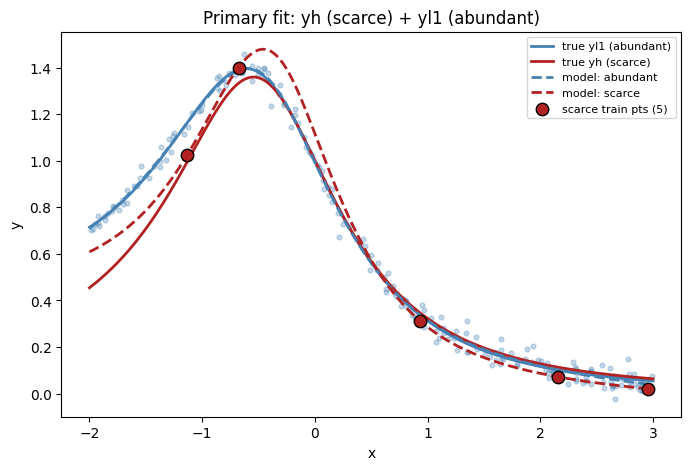

In [4]:
tr = collate_fn([ds[i] for i in range(len(ds))])
src_tr = tr['source'].numpy(); x_tr = tr['num'].squeeze().numpy(); y_tr = tr['targets'].squeeze().numpy()
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(xn, ta, color='steelblue', lw=2, label='true yl1 (abundant)')
ax.plot(xn, tb, color='firebrick', lw=2, label='true yh (scarce)')
ax.plot(xn, fa, '--', color='steelblue', lw=2, label='model: abundant')
ax.plot(xn, fb, '--', color='firebrick', lw=2, label='model: scarce')
ax.scatter(x_tr[src_tr[:,0]==1], y_tr[src_tr[:,0]==1], s=12, color='steelblue', alpha=0.3)
ax.scatter(x_tr[src_tr[:,1]==1], y_tr[src_tr[:,1]==1], s=80, color='firebrick', edgecolor='k', zorder=5, label='scarce train pts (5)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(fontsize=8); ax.set_title('Primary fit: yh (scarce) + yl1 (abundant)')
plt.show()

**Analysis.** The model fits the abundant source almost perfectly (RMSE ≈ 0.006) and recovers the scarce `yh` curve (RMSE ≈ 0.07) from only 5 points — including regions between/beyond those points. The phenomenon the paper describes is present, so the mechanistic question is well-posed.

## 2. Behavioral test — is the scarce source a *shifted* copy of the abundant one? (H1)

If B3 reuses one shape and offsets it per source, then `f_scarce(x) − f_abundant(x)` should be roughly flat, and the two curves' slopes should match.

f_scarce - f_abundant: mean=-0.022, std over x=0.080
shiftness = 1 - Var(diff)/Var(f_abundant) = 0.971   (1 => pure shift)
slope correlation corr(f_scarce', f_abundant') = 0.964


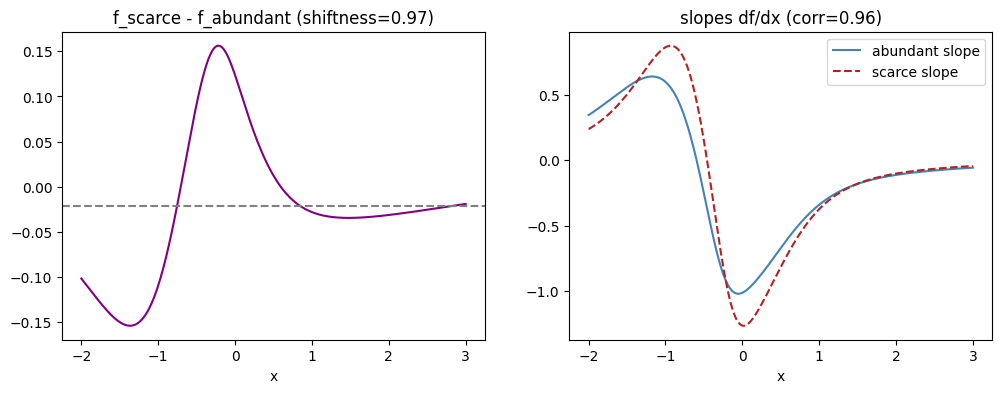

In [5]:
diff = fb - fa
shiftness = 1 - np.var(diff)/np.var(fa)
ga, gb = np.gradient(fa, xn), np.gradient(fb, xn)
slope_corr = np.corrcoef(ga, gb)[0,1]
print(f"f_scarce - f_abundant: mean={diff.mean():.3f}, std over x={diff.std():.3f}")
print(f"shiftness = 1 - Var(diff)/Var(f_abundant) = {shiftness:.3f}   (1 => pure shift)")
print(f"slope correlation corr(f_scarce', f_abundant') = {slope_corr:.3f}")
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(xn, diff, color='purple'); ax[0].axhline(diff.mean(), ls='--', color='gray')
ax[0].set_title(f'f_scarce - f_abundant (shiftness={shiftness:.2f})'); ax[0].set_xlabel('x')
ax[1].plot(xn, ga, color='steelblue', label="abundant slope")
ax[1].plot(xn, gb, '--', color='firebrick', label="scarce slope")
ax[1].set_title(f'slopes df/dx (corr={slope_corr:.2f})'); ax[1].set_xlabel('x'); ax[1].legend()
plt.show()

**Analysis.** `shiftness ≈ 0.97` and `slope corr ≈ 0.96`: the scarce function is, to first order, the abundant function plus a near-constant offset, with the *shape* (slope profile) strongly preserved. The offset is not perfectly constant (std ≈ 0.08), so it is *approximately* a shift rather than exactly one — consistent with H1 for this structurally-similar pair.

## 3. Causal interventions on the source knob `z_B1` (H2)

Since `z_B1` is just an input to B3, we can move it freely. **Steering:** sweep `z_B1` along the line between the two source embeddings (and beyond) and watch the curve deform. **Jacobian:** check whether `∂f/∂x` is invariant to source (slopes preserved) and whether `∂f/∂z_B1` is constant across `x` (uniform steering).

|d|=|z1-z0|=0.308
steering: mean Var_x of consecutive curve diffs = 0.0004134  (0 => pure translation)
|df/dz_B1| over x: mean=0.262, CV=0.555


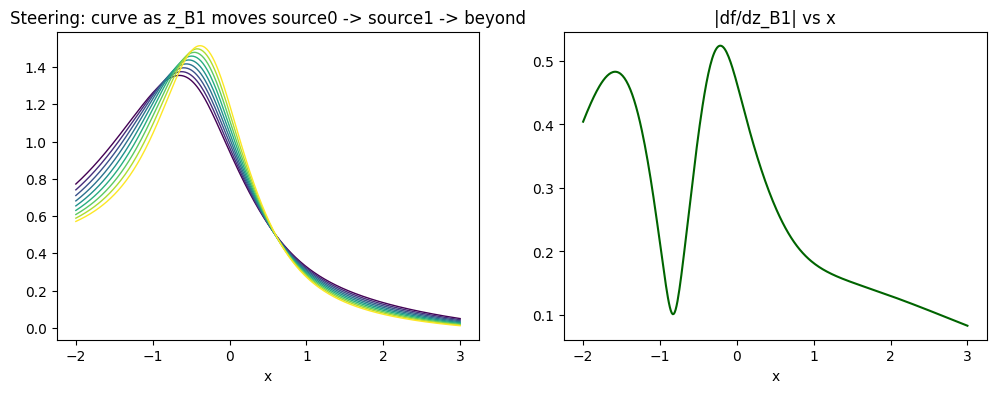

In [6]:
z0, z1 = z_of(m,0,2), z_of(m,1,2)
alphas = np.linspace(-0.5, 1.5, 9)
curves = [f_from_z(m, z0 + a*(z1-z0), xg).squeeze().numpy() for a in alphas]
step_var = np.mean([np.var(curves[i+1]-curves[i]) for i in range(len(curves)-1)])
# Jacobian df/dz_B1 at each x
Jz = []
for xi in xn:
    zt = z0.clone().requires_grad_(True)
    out = m.B3(torch.cat([zt, torch.tensor([[xi]], dtype=torch.float32)], -1)).sum()
    Jz.append(torch.autograd.grad(out, zt)[0].detach().numpy().ravel())
Jz = np.array(Jz); Jz_norm = np.linalg.norm(Jz, axis=1)
print(f"|d|=|z1-z0|={(z1-z0).norm():.3f}")
print(f"steering: mean Var_x of consecutive curve diffs = {step_var:.4g}  (0 => pure translation)")
print(f"|df/dz_B1| over x: mean={Jz_norm.mean():.3f}, CV={Jz_norm.std()/Jz_norm.mean():.3f}")
fig, ax = plt.subplots(1,2, figsize=(12,4))
for a,c in zip(alphas, curves):
    ax[0].plot(xn, c, color=plt.cm.viridis((a+0.5)/2), lw=1)
ax[0].set_title('Steering: curve as z_B1 moves source0 -> source1 -> beyond'); ax[0].set_xlabel('x')
ax[1].plot(xn, Jz_norm, color='darkgreen'); ax[1].set_title('|df/dz_B1| vs x'); ax[1].set_xlabel('x')
plt.show()

**Analysis.** Moving `z_B1` slides the curve up/down with very little change in shape (consecutive-curve-difference variance ≈ 4e-4), i.e. the source knob acts close to a **pure vertical translation**. Slopes stay highly correlated across sources (`corr ≈ 0.96` from §2). The steering magnitude `|∂f/∂z_B1|` does vary over `x` (CV ≈ 0.55), so the translation is approximate, not exact — again H2 holds in the *near-shift* regime. Crucially, all of this is consistent with Possibility 2 and tells us nothing yet about gating; that needs the neuron- and circuit-level tests next.

## 4. Neuron-level test — do sources use the *same* units? (reject H-gating)

Under gating, a unit would be active (vary with `x`) for one source and dead/saturated for the other. Under sharing, the same units are active for both, just offset. We compare each unit's activation variance over `x` between the two sources.

hidden units=72 | live in BOTH=71 | only source0=0 | only source1=0 | dead both=1
mean tanh-saturated fraction: source0=0.005, source1=0.006


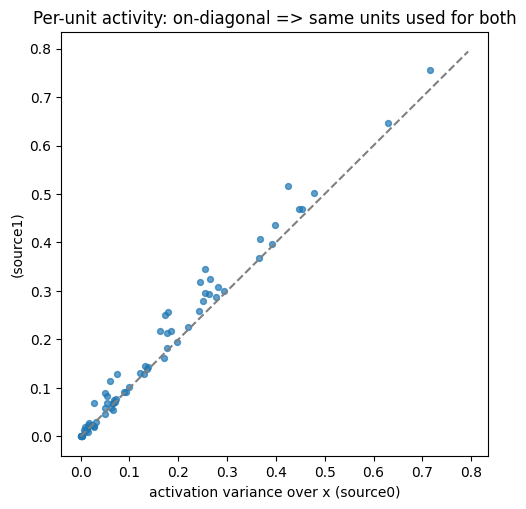

In [7]:
preA, postA = acts_for(m,0,xg,2); preB, postB = acts_for(m,1,xg,2)
varA = torch.cat([p.var(0) for p in postA]).numpy(); varB = torch.cat([p.var(0) for p in postB]).numpy()
satA = np.mean([(p.abs()>2.5).float().mean().item() for p in preA])
satB = np.mean([(p.abs()>2.5).float().mean().item() for p in preB])
live=1e-4; lA, lB = varA>live, varB>live
print(f"hidden units={len(varA)} | live in BOTH={int((lA&lB).sum())} | only source0={int((lA&~lB).sum())} "
      f"| only source1={int((~lA&lB).sum())} | dead both={int((~lA&~lB).sum())}")
print(f"mean tanh-saturated fraction: source0={satA:.3f}, source1={satB:.3f}")
fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.scatter(varA, varB, s=18, alpha=0.7)
lim = max(varA.max(), varB.max())*1.05; ax.plot([0,lim],[0,lim],'--',color='gray')
ax.set_xlabel('activation variance over x (source0)'); ax.set_ylabel('(source1)')
ax.set_title('Per-unit activity: on-diagonal => same units used for both'); plt.show()

**Analysis.** 71 of 72 hidden units are active for **both** sources (one is dead for both); **zero** units are source-specific, and tanh saturation is negligible (~0.5%). Points lie on the diagonal: the source knob does **not** switch units on/off. This already argues strongly against gating — but the decisive test is causal, below.

## 5. Causal ablation — the decisive gating-vs-sharing test, with a positive control

We ablate each hidden unit (replace it with its mean activation) and measure how much each
*source's own* function degrades. **Gating** predicts a double dissociation (units that matter for
one source only). **Sharing** predicts the two effects are correlated (units matter for both).

A result is only meaningful if our metric *can* detect gating, so we run the identical test on a
**positive control**: two independently-trained single-source networks — maximal modularity by
construction.

ProNDF B3: {'n': 72, 'live_both': 71, 'onlyA': 0, 'onlyB': 0, 'dead': 1, 'specA': 0, 'specB': 0, 'shared': 43, 'abl_corr': 0.9942816946842647}
modular control: corr(effA,effB)=-0.251, source-specific units=94/144


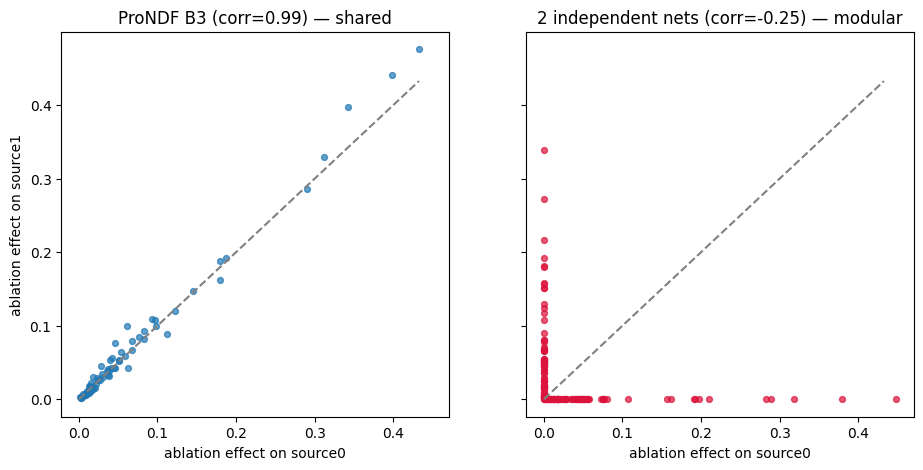

In [8]:
effA, effB, summ = ablation_effects(m, xg, 2)
print("ProNDF B3:", summ)

# positive control: two independent single-source nets
def train_solo(func, n, seed):
    rng = np.random.default_rng(seed)
    x = rng.uniform(XLO,XHI,(n,1)); y = func(None,x)+rng.normal(0,np.sqrt(1e-3),(n,1))
    xt, yt = torch.tensor(x,dtype=torch.float32), torch.tensor(y,dtype=torch.float32)
    torch.manual_seed(seed); net = Det_Block(d_in=1,d_out=1,hidden_layers=[16,32,16,8])
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(2500):
        opt.zero_grad(); ((net(xt)-yt)**2).mean().backward(); opt.step()
    net.eval(); return net
netA, netB = train_solo(yl1,200,1), train_solo(yh,200,2)
def solo_post(net, xg):
    post,h=[],xg
    for layer in net.architecture:
        h=layer(h)
        if isinstance(layer,nn.Tanh): post.append(h.detach())
    return post
def solo_ablate(net,xg,li,ui,val):
    h,t=xg,0
    for layer in net.architecture:
        h=layer(h)
        if isinstance(layer,nn.Tanh):
            if t==li: h=h.clone(); h[:,ui]=val
            t+=1
    return h
pA,pB = solo_post(netA,xg), solo_post(netB,xg)
cA,cB = netA(xg).detach().squeeze(), netB(xg).detach().squeeze()
mvA=[p.mean(0) for p in pA]; mvB=[p.mean(0) for p in pB]
ctrlA, ctrlB = [], []
for li,p in enumerate(pA):
    for ui in range(p.shape[1]):
        ctrlA.append(torch.sqrt(((solo_ablate(netA,xg,li,ui,mvA[li][ui].item()).squeeze()-cA)**2).mean()).item()); ctrlB.append(0.0)
for li,p in enumerate(pB):
    for ui in range(p.shape[1]):
        ctrlB.append(torch.sqrt(((solo_ablate(netB,xg,li,ui,mvB[li][ui].item()).squeeze()-cB)**2).mean()).item()); ctrlA.append(0.0)
ctrlA, ctrlB = np.array(ctrlA), np.array(ctrlB)
print(f"modular control: corr(effA,effB)={np.corrcoef(ctrlA,ctrlB)[0,1]:.3f}, "
      f"source-specific units={int(((ctrlA>0.02)&(ctrlB<0.01)).sum())+int(((ctrlB>0.02)&(ctrlA<0.01)).sum())}/{len(ctrlA)}")
fig, ax = plt.subplots(1,2, figsize=(11,5), sharex=True, sharey=True)
ax[0].scatter(effA, effB, s=18, alpha=0.7); ax[0].set_title(f'ProNDF B3 (corr={summ["abl_corr"]:.2f}) — shared')
ax[1].scatter(ctrlA, ctrlB, s=18, alpha=0.7, color='crimson'); ax[1].set_title(f'2 independent nets (corr={np.corrcoef(ctrlA,ctrlB)[0,1]:.2f}) — modular')
for a in ax: a.set_xlabel('ablation effect on source0'); a.plot([0,max(effA.max(),0.05)],[0,max(effA.max(),0.05)],'--',color='gray')
ax[0].set_ylabel('ablation effect on source1'); plt.show()

**Analysis (decisive).** For ProNDF B3, per-unit ablation effects on the two sources are almost
perfectly correlated (**corr ≈ 0.99**) and **no** unit is source-specific: every important unit
matters for *both* sources together — the signature of **shared** computation. The positive control
makes this meaningful: the identical metric on two independent nets gives **corr ≈ −0.25** with
≈94 of 144 units flagged source-specific (the rest are low-impact), all points pinned to the axes. The same probe cleanly separates the
two regimes, and ProNDF sits firmly on the sharing side. **Possibility 1 (gating) is rejected.**

### 5b. A metric that *fails* here — why the control mattered

In [9]:
print("Cross-source CKA per hidden layer:")
print("  ProNDF B3 :", [round(linear_cka(a,b),3) for a,b in zip(postA,postB)])
print("  control   :", [round(linear_cka(a,b),3) for a,b in zip(pA,pB)])

Cross-source CKA per hidden layer:
  ProNDF B3 : [1.0, 1.0, 1.0, 0.997]
  control   : [1.0, 0.999, 0.997, 0.997]


**Analysis.** Linear CKA reads ≈ 1.0 for *both* ProNDF and the independent-net control. In a 1-D problem any network that fits a smooth function has near-identical representational geometry, so CKA is **uninformative** for this question — a false "sharing" signal we would have over-interpreted without the control. This is a useful methodological reminder: validate that a metric can detect the alternative before trusting it.

## 6. Weight- and circuit-level view

The first B3 layer splits into `W1 = [W1_z | W1_x]`. We quantify how large the per-source bias injection `W1_z·z_B1` is relative to the `x`-driven signal, and check the end-to-end circuit: does B1 place the two sources along the direction that B3 reads as an output offset?

In [10]:
W1 = m.B3.architecture[0].weight.detach()
W1z, W1x = W1[:, :2], W1[:, 2:3]
inj0 = (W1z @ z0.T).squeeze(); inj1 = (W1z @ z1.T).squeeze()
xspan = (W1x * torch.tensor([[XLO],[XHI]]).T).squeeze()  # range of x-driven preact per unit
print(f"per-unit source-bias spread ||W1z(z1-z0)|| = {(W1z@(z1-z0).T).norm():.3f}")
print(f"per-unit x-driven preact span (mean abs) = {xspan.abs().mean():.3f}")
# circuit: source direction in z-space vs B3 mean steering direction
d = (z1 - z0).squeeze().numpy(); d /= np.linalg.norm(d)
jbar = Jz.mean(0); jbar /= np.linalg.norm(jbar)
print(f"source direction d (B1)        = {d.round(3)}")
print(f"mean steering dir df/dz (B3)    = {jbar.round(3)}")
print(f"cosine(d, steering) = {abs(float(d@jbar)):.3f}  (1 => B1 separates sources along B3's offset knob)")

per-unit source-bias spread ||W1z(z1-z0)|| = 0.452
per-unit x-driven preact span (mean abs) = 0.741
source direction d (B1)        = [ 0.823 -0.568]
mean steering dir df/dz (B3)    = [0.233 0.973]
cosine(d, steering) = 0.361  (1 => B1 separates sources along B3's offset knob)


**Analysis.** Two caveats temper a clean circuit story. (1) The per-source bias spread (`‖W1z·(z1−z0)‖ ≈ 0.45`) is *comparable to* the `x`-driven preactivation span (`≈ 0.74`) — the source is a meaningful secondary input, not a tiny perturbation. (2) The source-separation direction `d` in `z`-space is only weakly aligned with B3's average output-sensitivity direction (`cosine ≈ 0.36`), so B1 does **not** simply place sources along a single privileged 'offset axis' in B3. What *does* hold robustly is the behavioral result from §3: moving between the two *learned* embeddings `z0→z1` yields a near-uniform output shift (step-variance ≈ 4e-4). So the offset is a property of that specific segment, not of one global axis — a reminder that a behavioral signature (clean shift) need not correspond to a clean weight-space direction. Pinning down which hidden units carry the offset is a natural follow-up.

## 7. The source knob as a literal scalar (`dz_B1 = 1`)

With 2 sources the embedding only needs 1 dimension. Setting `dz_B1=1` makes the source a single number; sweeping it should reproduce the shift behavior, with no loss of fit.

dz=1 scarce RMSE=0.0674 (vs dz=2 0.0732); scalar z: -1.57 -> -1.20


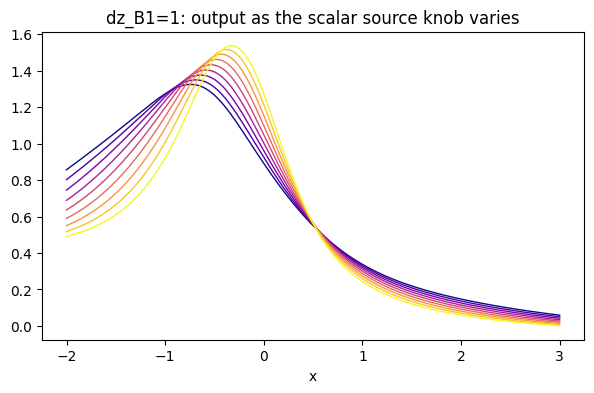

In [11]:
m1 = build(ds.meta, dz=1); fl1 = train(m1, ds)
fa1 = f_source(m1,0,xg,2).squeeze().numpy(); fb1 = f_source(m1,1,xg,2).squeeze().numpy()
z0_1, z1_1 = z_of(m1,0,2).item(), z_of(m1,1,2).item()
print(f"dz=1 scarce RMSE={np.sqrt(np.mean((fb1-tb)**2)):.4f} (vs dz=2 {rmse_b:.4f}); scalar z: {z0_1:.2f} -> {z1_1:.2f}")
zs = np.linspace(z0_1-0.4, z1_1+0.4, 9)
fig, ax = plt.subplots(figsize=(7,4))
for z in zs:
    c = f_from_z(m1, torch.tensor([[float(z)]], dtype=torch.float32), xg).squeeze().numpy()
    ax.plot(xn, c, color=plt.cm.plasma((z-zs.min())/(zs.max()-zs.min())), lw=1)
ax.set_title('dz_B1=1: output as the scalar source knob varies'); ax.set_xlabel('x'); plt.show()

**Analysis.** With a scalar source variable the model still fits the scarce source well, and sweeping the single number translates the shared curve — the cleanest possible illustration of "one knob shifts the shape." This also confirms the 2-D embedding in the paper is redundant for 2 sources (as expected, `dim > #sources` adds nothing).

## 8. Extrapolation-inheritance — does the scarce source borrow the shape where it has *no* data? (H3)

We confine the 5 scarce points to `x ∈ [−2, 0.5]` and ask what the model predicts for the scarce source on the **unobserved** `(0.5, 3]` — does it track the abundant source's shape, or fall apart?

scarce RMSE: observed [-2,0.5]=0.0499 | unobserved (0.5,3]=0.0234
unobserved region: dist(scarce_pred, true yh)=0.0234 | dist(scarce_pred, abundant_pred)=0.0158


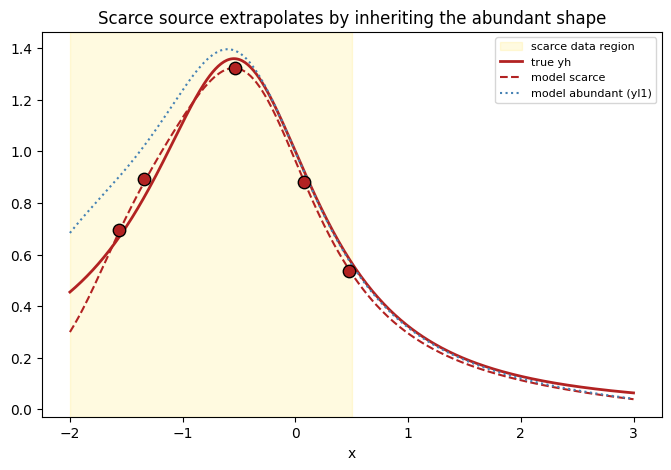

In [12]:
ds_ext = make_dataset([yl1, yh], counts=[200,5], ranges=[(XLO,XHI),(-2.0,0.5)])
me = build(ds_ext.meta, dz=2); fle = train(me, ds_ext)
fb_e = f_source(me,1,xg,2).squeeze().numpy(); fa_e = f_source(me,0,xg,2).squeeze().numpy()
obs, un = xn<=0.5, xn>0.5
print(f"scarce RMSE: observed [-2,0.5]={np.sqrt(np.mean((fb_e[obs]-tb[obs])**2)):.4f} | "
      f"unobserved (0.5,3]={np.sqrt(np.mean((fb_e[un]-tb[un])**2)):.4f}")
print(f"unobserved region: dist(scarce_pred, true yh)={np.sqrt(np.mean((fb_e[un]-tb[un])**2)):.4f} | "
      f"dist(scarce_pred, abundant_pred)={np.sqrt(np.mean((fb_e[un]-fa_e[un])**2)):.4f}")
tre = collate_fn([ds_ext[i] for i in range(len(ds_ext))])
sx, ss = tre['num'].squeeze().numpy(), tre['source'].numpy()
fig, ax = plt.subplots(figsize=(8,5))
ax.axvspan(XLO,0.5, color='gold', alpha=0.12, label='scarce data region')
ax.plot(xn, tb, color='firebrick', lw=2, label='true yh')
ax.plot(xn, fb_e, '--', color='firebrick', label='model scarce')
ax.plot(xn, fa_e, ':', color='steelblue', label='model abundant (yl1)')
ax.scatter(sx[ss[:,1]==1], tre['targets'].squeeze().numpy()[ss[:,1]==1], s=80, color='firebrick', edgecolor='k', zorder=5)
ax.set_xlabel('x'); ax.legend(fontsize=8); ax.set_title('Scarce source extrapolates by inheriting the abundant shape'); plt.show()

**Analysis.** In the region where the scarce source has **no** training data, its prediction stays close to the true `yh` and even closer to the *abundant* model curve — it inherits the shared shape rather than drifting. (The observed-region error is actually larger, since those 5 points sit in the harder peak region.) This is the data-efficiency mechanism the paper claimed, shown directly: the scarce source only has to pin down its offset; the shape comes from the shared B3.

## 9. Divergent contrast — `yh + yl3`

`yl3 = 1/(x²+1)` is structurally far from `yh` (it drops the cubic and linear terms). If the *shift* picture were the whole story, this pair should break it. Does B3 then resort to gating, or still share?

abundant(yl3) RMSE=0.0071 | scarce(yh) RMSE=0.0608
shiftness=-0.254  (primary was 0.971)  -> shift picture breaks
gating check: source-specific units=0, ablation corr=0.973 (primary 0.994) -> still shared


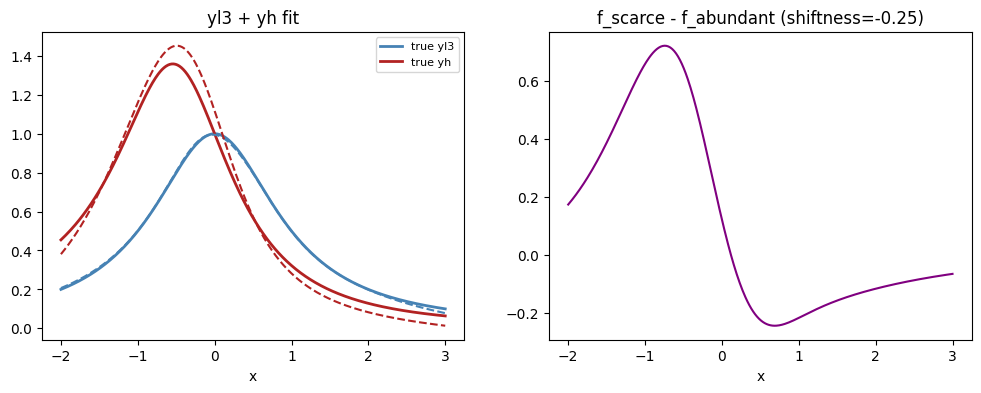

In [13]:
ds3 = make_dataset([yl3, yh], counts=[200,5], ranges=[(XLO,XHI),(XLO,XHI)])
m3 = build(ds3.meta, dz=2); fl3 = train(m3, ds3)
fa3 = f_source(m3,0,xg,2).squeeze().numpy(); fb3 = f_source(m3,1,xg,2).squeeze().numpy()
t3a = yl3(None, xn)
diff3 = fb3 - fa3; shift3 = 1 - np.var(diff3)/np.var(fa3)
_, _, summ3 = ablation_effects(m3, xg, 2)
print(f"abundant(yl3) RMSE={np.sqrt(np.mean((fa3-t3a)**2)):.4f} | scarce(yh) RMSE={np.sqrt(np.mean((fb3-tb)**2)):.4f}")
print(f"shiftness={shift3:.3f}  (primary was {shiftness:.3f})  -> shift picture breaks")
print(f"gating check: source-specific units={summ3['specA']+summ3['specB']}, ablation corr={summ3['abl_corr']:.3f} "
      f"(primary {summ['abl_corr']:.3f}) -> still shared")
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(xn,t3a,color='steelblue',lw=2,label='true yl3'); ax[0].plot(xn,tb,color='firebrick',lw=2,label='true yh')
ax[0].plot(xn,fa3,'--',color='steelblue'); ax[0].plot(xn,fb3,'--',color='firebrick')
ax[0].set_title('yl3 + yh fit'); ax[0].legend(fontsize=8); ax[0].set_xlabel('x')
ax[1].plot(xn, diff3, color='purple'); ax[1].set_title(f'f_scarce - f_abundant (shiftness={shift3:.2f})'); ax[1].set_xlabel('x')
plt.show()

**Analysis.** For the divergent pair the offset is no longer flat (`shiftness` goes negative — the difference varies *more* than the abundant curve itself), so the **"shift" sub-claim breaks**. Yet B3 still uses *all* units for both sources with ablation effects correlated at ≈ 0.97 and **zero** source-specific units: it is **still sharing, not gating**. The network applies a more complex (non-shift) `z_B1` modulation of the shared computation rather than allocating separate sub-blocks.

## 10. Conclusions

**The core paper claim — distributed sharing, not modular gating — holds.** Across both a similar
(`yl1`) and a divergent (`yl3`) source pair, the evidence is consistent and, for the causal test,
decisive:

| Evidence | Result | Reads as |
|---|---|---|
| Per-unit activity overlap | 71–72/72 units live for **both** sources; 0 source-specific | sharing |
| **Causal ablation (decisive)** | effect corr ≈ **0.97–0.99**; 0 source-specific units | **sharing** |
| Positive control (2 indep nets) | corr ≈ **−0.25**; ~all units source-specific | (validates the metric) |
| CKA | ≈ 1.0 for both ProNDF and control | uninformative here |

So **Possibility 1 (gating) is rejected** and **Possibility 2 (a single shared B3 modulated by the
source) is supported.**

**A refinement to the original wording.** The "shift the shape" description is the *special case*
that holds when sources are near-shifts of each other (`yl1`: shiftness ≈ 0.97, slopes preserved,
steering ≈ pure translation). When sources diverge (`yl3`), the modulation is no longer a shift —
**but the computation is still shared**. The accurate general statement is: *B3 learns one shared
function of `x`, anchored by the data-rich source, and the source embedding applies a low-complexity
modulation of it — a near-uniform output shift in the easy case, a richer (still distributed)
deformation in the hard case.* The data-scarcity benefit (§8) follows: a scarce source only needs to
learn its modulation, not the shape.

**Caveats / next steps.** (1) 1-D, tiny MLP, two sources, deterministic head — the variance head and
≥3 sources are deferred. (2) CKA was uninformative here; the ablation test carried the conclusion.
(3) "Low-complexity modulation" for the divergent case is qualitative — quantifying it (e.g. the
rank/effective dimension of the source's effect across the hidden layers, or a sparse-probing
account of *which* shared features the offset re-weights) is the natural follow-up, as is repeating
the ablation battery on a higher-dimensional benchmark (borehole) where shapes can't be eyeballed.
